In [20]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("PlayTennis.csv")

df

,Outlook,Temperature,Humidity,Wind,Play Tennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [21]:
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

Shape: (14, 5)

Missing values:
Outlook        0
Temperature    0
Humidity       0
Wind           0
Decision       0
dtype: int64


In [4]:
df["Decision"] = df["Play Tennis"].map({
    "Yes": "Go Out",
    "No": "Stay In"
})

df = df.drop("Play Tennis", axis=1)

df

,Outlook,Temperature,Humidity,Wind,Decision
0,Sunny,Hot,High,Weak,Stay In
1,Sunny,Hot,High,Strong,Stay In
2,Overcast,Hot,High,Weak,Go Out
3,Rain,Mild,High,Weak,Go Out
4,Rain,Cool,Normal,Weak,Go Out
5,Rain,Cool,Normal,Strong,Stay In
6,Overcast,Cool,Normal,Strong,Go Out
7,Sunny,Mild,High,Weak,Stay In
8,Sunny,Cool,Normal,Weak,Go Out
9,Rain,Mild,Normal,Weak,Go Out


In [22]:
X = df.drop("Decision", axis=1)
y = df["Decision"]

X_encoded = pd.get_dummies(X).astype(int)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Encoded Input:")
display(X_encoded)

print("Classes:", label_encoder.classes_)

Encoded Input:


,Outlook_Overcast,Outlook_Rain,Outlook_Sunny,Temperature_Cool,Temperature_Hot,Temperature_Mild,Humidity_High,Humidity_Normal,Wind_Strong,Wind_Weak
0,0,0,1,0,1,0,1,0,0,1
1,0,0,1,0,1,0,1,0,1,0
2,1,0,0,0,1,0,1,0,0,1
3,0,1,0,0,0,1,1,0,0,1
4,0,1,0,1,0,0,0,1,0,1
5,0,1,0,1,0,0,0,1,1,0
6,1,0,0,1,0,0,0,1,1,0
7,0,0,1,0,0,1,1,0,0,1
8,0,0,1,1,0,0,0,1,0,1
9,0,1,0,0,0,1,0,1,0,1


Classes: ['Go Out' 'Stay In']


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.30,
    random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (9, 10)
Testing size: (5, 10)


In [24]:
model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [25]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Accuracy: 0.6
Accuracy Percentage: 60.0 %


In [26]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Confusion Matrix:
[[2 1]
 [1 1]]

Classification Report:
              precision    recall  f1-score   support

      Go Out       0.67      0.67      0.67         3
     Stay In       0.50      0.50      0.50         2

    accuracy                           0.60         5
   macro avg       0.58      0.58      0.58         5
weighted avg       0.60      0.60      0.60         5



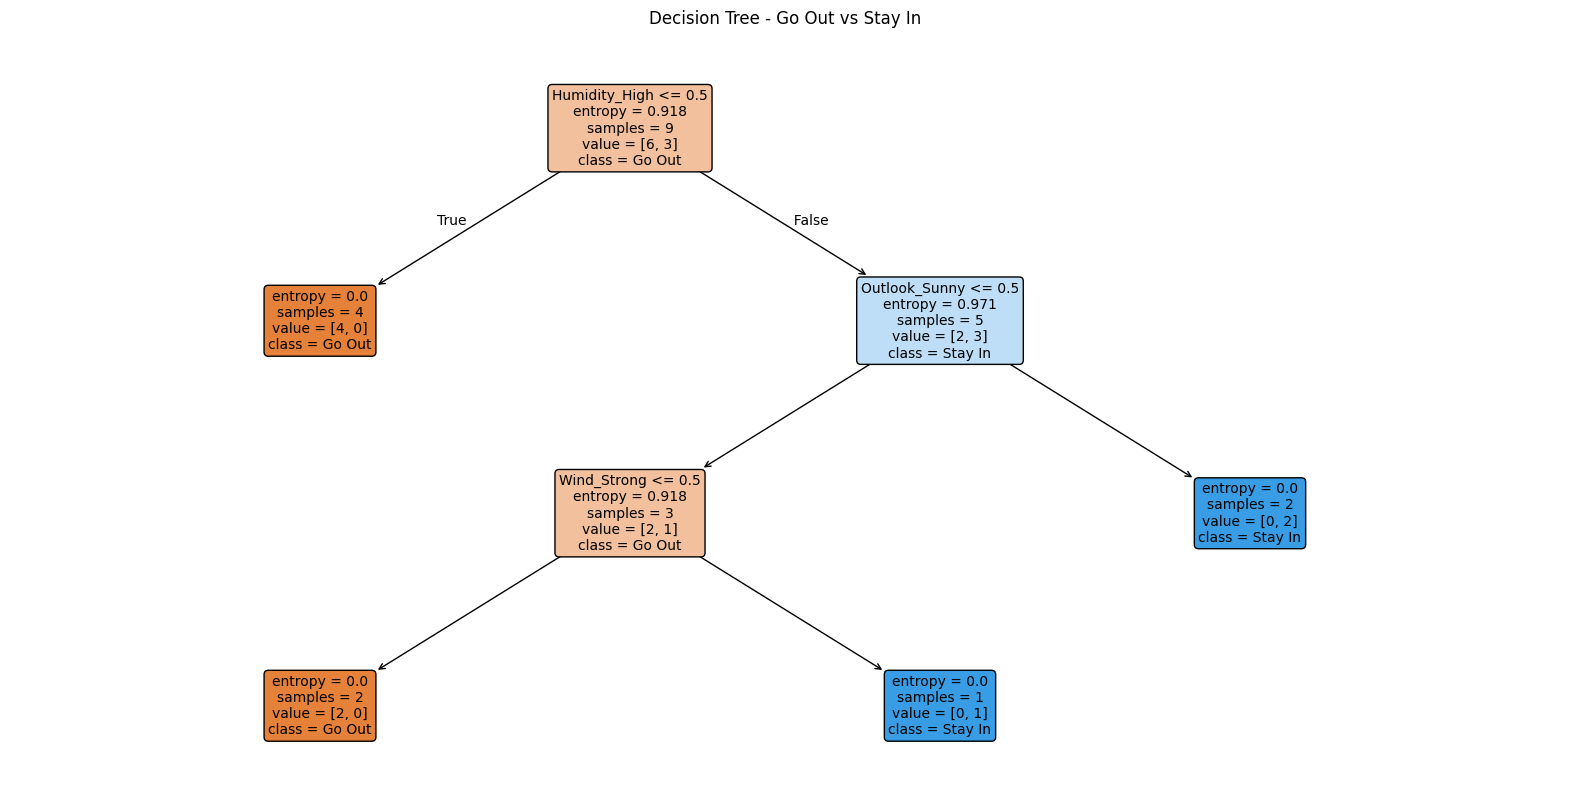

In [27]:
plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X_encoded.columns,
    class_names=label_encoder.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree - Go Out vs Stay In")

plt.show()

In [28]:
new_data = pd.DataFrame({
    "Outlook": ["Sunny"],
    "Temperature": ["Mild"],
    "Humidity": ["High"],
    "Wind": ["Strong"]
})

new_encoded = pd.get_dummies(new_data)

new_encoded = new_encoded.reindex(
    columns=X_encoded.columns,
    fill_value=0
)

prediction = model.predict(new_encoded)

result = label_encoder.inverse_transform(prediction)

print("Input Weather:")
display(new_data)

print("Decision:", result[0])

Input Weather:


,Outlook,Temperature,Humidity,Wind
0,Sunny,Mild,High,Strong


Decision: Stay In
